## Experiment: Local Search Algorithms (Hill Climbing)

### Simple Example: Finding the maximum of a 1D quadratic function using Hill Climbing

This simple example demonstrates the core concept of Hill Climbing: starting from a random point and iteratively moving to a better neighboring point until no improvement can be made.

In [1]:
# Import necessary libraries.
import random # Used for generating random starting points and neighbor perturbations.

# 1. Define the objective function (the function we want to maximize).
# This function represents a simple parabola: f(x) = -(x - 5)^2 + 25.
# Its maximum is at x = 5, where f(x) = 25.
def objective_function_1d(x):
    """Calculates the value of the 1D objective function."""
    return -(x - 5)**2 + 25

# 2. Implement the Hill Climbing algorithm.
def hill_climbing_1d(objective_func, initial_solution_range, step_size, max_iterations=100):
    """Performs Hill Climbing to find a local maximum of a 1D function."""

    # Initialize with a random starting point within the given range.
    current_solution = random.uniform(initial_solution_range[0], initial_solution_range[1])
    # Evaluate the objective function at the current solution.
    current_value = objective_func(current_solution)

    print(f"Starting Hill Climbing from x = {current_solution:.2f}, f(x) = {current_value:.2f}")

    # Iterate for a fixed number of times or until no improvement is found.
    for i in range(max_iterations):
        # Generate potential neighbors by taking a small step in both positive and negative directions.
        neighbor_left = current_solution - step_size
        neighbor_right = current_solution + step_size

        # Evaluate the objective function for the neighbors.
        value_left = objective_func(neighbor_left)
        value_right = objective_func(neighbor_right)

        # Assume no better neighbor is found initially in this iteration.
        best_neighbor_found = False

        # Check if moving left improves the solution.
        if value_left > current_value:
            current_solution = neighbor_left # Update current solution to the better neighbor.
            current_value = value_left       # Update the current objective value.
            best_neighbor_found = True       # Mark that a better neighbor was found.

        # Check if moving right improves the solution (only if moving left didn't result in a better solution than the current one).
        # Note: If both improve, this simple check prioritizes left or right based on order. A more robust approach would compare all neighbors.
        if value_right > current_value:
            current_solution = neighbor_right
            current_value = value_right
            best_neighbor_found = True

        # If no better neighbor was found in this iteration, we've reached a local optimum.
        if not best_neighbor_found:
            print(f"\nReached local optimum at iteration {i+1}.")
            break # Exit the loop as no further improvement is possible.

        print(f"Iteration {i+1}: Current solution x = {current_solution:.2f}, f(x) = {current_value:.2f}")

    # Return the best solution found.
    return current_solution, current_value

# 3. Run the Hill Climbing algorithm.
# Define the range for initial solution and the step size for exploring neighbors.
initial_range = (-10, 20) # Search space for x.
step = 0.1             # How much to perturb the solution to find neighbors.

# Execute the algorithm.
best_x, max_f_x = hill_climbing_1d(objective_function_1d, initial_range, step)

# 4. Display the results.
print(f"\n--- Simple Hill Climbing Results ---")
print(f"Optimal x found: {best_x:.2f}")
print(f"Maximum f(x) found: {max_f_x:.2f}")


Starting Hill Climbing from x = -4.65, f(x) = -68.06
Iteration 1: Current solution x = -4.55, f(x) = -66.15
Iteration 2: Current solution x = -4.45, f(x) = -64.25
Iteration 3: Current solution x = -4.35, f(x) = -62.37
Iteration 4: Current solution x = -4.25, f(x) = -60.51
Iteration 5: Current solution x = -4.15, f(x) = -58.67
Iteration 6: Current solution x = -4.05, f(x) = -56.85
Iteration 7: Current solution x = -3.95, f(x) = -55.05
Iteration 8: Current solution x = -3.85, f(x) = -53.27
Iteration 9: Current solution x = -3.75, f(x) = -51.51
Iteration 10: Current solution x = -3.65, f(x) = -49.77
Iteration 11: Current solution x = -3.55, f(x) = -48.05
Iteration 12: Current solution x = -3.45, f(x) = -46.35
Iteration 13: Current solution x = -3.35, f(x) = -44.67
Iteration 14: Current solution x = -3.25, f(x) = -43.01
Iteration 15: Current solution x = -3.15, f(x) = -41.37
Iteration 16: Current solution x = -3.05, f(x) = -39.75
Iteration 17: Current solution x = -2.95, f(x) = -38.16
Iter

### Complex Application: Optimizing a 2D Multimodal Function using Hill Climbing

This example applies Hill Climbing to a 2D function with multiple local maxima, demonstrating how the algorithm can get stuck in a local optimum depending on the starting point. The function used is a variation of a Rastrigin-like function, which is often used in optimization benchmarks because of its many local optima.

$f(x, y) = -((x-2)^2 + (y-3)^2 + 10 \cdot \cos(2 \pi x) + 10 \cdot \cos(2 \pi y))$

Starting Hill Climbing from (x=-1.15, y=4.62), f(x,y)=-11.48

Reached local optimum at iteration 4.

--- Complex Hill Climbing Results ---
Optimal (x, y) found: (-1.45, 4.52)
Maximum f(x,y) found: 5.12


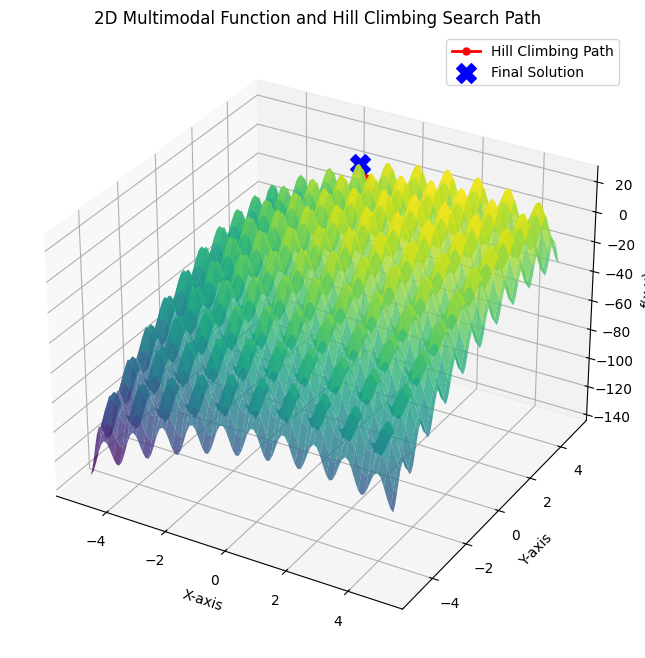

In [3]:
# Import necessary libraries.
import random # Used for generating random starting points and neighbor perturbations.
import math   # Used for mathematical functions like cos and pi.
import matplotlib.pyplot as plt # Used for plotting the function and search path.
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting.
import numpy as np # Used for numerical operations, especially for generating plot data.

# 1. Define the 2D multimodal objective function.
# This function has multiple local maxima and is more challenging for simple Hill Climbing.
def objective_function_2d(x, y):
    """Calculates the value of a 2D multimodal objective function."""
    # A variation of a function designed to have multiple local optima.
    # The global maximum is around (2, 3).
    return -((x-2)**2 + (y-3)**2 + 10 * math.cos(2 * math.pi * x) + 10 * math.cos(2 * math.pi * y))

# 2. Implement the Hill Climbing algorithm for 2D.
def hill_climbing_2d(objective_func, x_range, y_range, step_size, max_iterations=1000):
    """Performs Hill Climbing to find a local maximum of a 2D function."""

    # Initialize with a random starting point (x, y) within the given ranges.
    current_x = random.uniform(x_range[0], x_range[1])
    current_y = random.uniform(y_range[0], y_range[1])
    # Evaluate the objective function at the current solution.
    current_value = objective_func(current_x, current_y)

    # Store the path taken by the algorithm for visualization.
    path = [(current_x, current_y, current_value)]

    print(f"Starting Hill Climbing from (x={current_x:.2f}, y={current_y:.2f}), f(x,y)={current_value:.2f}")

    # Iterate for a fixed number of times.
    for i in range(max_iterations):
        # Generate 8 neighbors (up, down, left, right, and diagonals) around the current solution.
        neighbors = [
            (current_x + step_size, current_y),        # Right
            (current_x - step_size, current_y),        # Left
            (current_x, current_y + step_size),        # Up
            (current_x, current_y - step_size),        # Down
            (current_x + step_size, current_y + step_size), # Up-Right
            (current_x - step_size, current_y - step_size), # Down-Left
            (current_x + step_size, current_y - step_size), # Down-Right
            (current_x - step_size, current_y + step_size)  # Up-Left
        ]

        # Find the best neighbor.
        best_neighbor_x, best_neighbor_y = current_x, current_y
        best_neighbor_value = current_value
        best_neighbor_found = False

        for nx, ny in neighbors:
            # Ensure neighbors are within bounds (optional, but good practice).
            if x_range[0] <= nx <= x_range[1] and y_range[0] <= ny <= y_range[1]:
                neighbor_value = objective_func(nx, ny)
                # If a neighbor has a better value, update the best neighbor.
                if neighbor_value > best_neighbor_value:
                    best_neighbor_x, best_neighbor_y = nx, ny
                    best_neighbor_value = neighbor_value
                    best_neighbor_found = True

        # If the best neighbor found is better than the current solution, move to it.
        if best_neighbor_found and best_neighbor_value > current_value:
            current_x, current_y = best_neighbor_x, best_neighbor_y
            current_value = best_neighbor_value
            path.append((current_x, current_y, current_value))
        else:
            # If no better neighbor is found, we've reached a local optimum.
            print(f"\nReached local optimum at iteration {i+1}.")
            break # Exit the loop.

        # Periodically print progress.
        if (i + 1) % 100 == 0:
            print(f"Iteration {i+1}: Current solution (x={current_x:.2f}, y={current_y:.2f}), f(x,y)={current_value:.2f}")

    # Return the best solution found and the path.
    return current_x, current_y, current_value, path

# 3. Run the Hill Climbing algorithm.
# Define the search ranges for x and y, and the step size.
x_range_2d = (-5, 5)
y_range_2d = (-5, 5)
step_2d = 0.1

best_x_2d, best_y_2d, max_f_xy_2d, search_path = hill_climbing_2d(objective_function_2d, x_range_2d, y_range_2d, step_2d)

# 4. Display the results.
print(f"\n--- Complex Hill Climbing Results ---")
print(f"Optimal (x, y) found: ({best_x_2d:.2f}, {best_y_2d:.2f})")
print(f"Maximum f(x,y) found: {max_f_xy_2d:.2f}")

# 5. Visualize the objective function and the search path.
# Create a meshgrid for plotting the 3D surface.
X = np.linspace(x_range_2d[0], x_range_2d[1], 100)
Y = np.linspace(y_range_2d[0], y_range_2d[1], 100)
X, Y = np.meshgrid(X, Y)

# Vectorize the objective function to apply it directly to the meshgrid arrays
vectorized_objective_function_2d = np.vectorize(objective_function_2d)
Z = vectorized_objective_function_2d(X, Y) # Calculate Z values for the surface.

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') # Create a 3D subplot.

# Plot the surface.
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, antialiased=True)

# Plot the search path.
path_x, path_y, path_z = zip(*search_path) # Unpack the path data.
ax.plot(path_x, path_y, path_z, color='red', marker='o', markersize=5, linestyle='-', linewidth=2, label='Hill Climbing Path')

# Mark the final solution.
ax.scatter(best_x_2d, best_y_2d, max_f_xy_2d, color='blue', marker='X', s=200, label='Final Solution')

ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('f(x,y)')
ax.set_title('2D Multimodal Function and Hill Climbing Search Path')
ax.legend()
plt.show()
